In [153]:
from analyses import parse
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import polars as pl
import numpy as np
import colorir as cl
from pathlib import Path
from tqdm import tqdm

In [154]:
sim_paths = {}
for path in Path("../runs/speed/").iterdir():
    sim_type = path.name
    gamma = 20 - int(sim_type.split("-")[1])
    for replica_path in path.iterdir():
        replica = int(replica_path.name)
        sim_paths[(gamma, replica)] = replica_path
sims = parse.parse_cells_multiple(sim_paths.values(), 30)
sim_ids = list(sim_paths.keys())
for i in range(len(sims)):
    sims[i] = sims[i].with_columns(
        gamma=sim_ids[i][0], 
        sim_replica=sim_ids[i][1]
    )
cellveldf = pl.concat(sims)

In [155]:
# Analyse whole duration if never reaches peak (replace 180 to change that)
stdf = cellveldf\
    .with_columns(displ=(pl.col("center_x") ** 2 + pl.col("center_y") ** 2) ** 0.5)\
    .with_columns(mean_displ=pl.col("displ").mean().over(["gamma", "sim_replica", "wtime"]))\
    .filter(pl.col("wtime") > 25e4)\
    .sort("wtime")\
    .group_by("gamma")\
    .agg(
        steady_time=pl.col("wtime").filter(pl.col("mean_displ") <= 180).min()
    )\
    .fill_null(cellveldf["wtime"].max())\
    .sort("gamma")
stdf

gamma,steady_time
i32,i32
0,14900000
2,14900000
4,14900000
6,14900000
8,14900000
…,…
12,1300000
14,1400000
16,1500000


In [156]:
# These sims should contain a single cell!!
sim_paths = {}
for sp in Path("../runs/msd/").iterdir():
    sim_type = sp.name
    gamma = 20 - int(sim_type.split("-")[1])
    for p in sp.iterdir():
        replica = int(p.name)
        sim_paths[(gamma, replica)] = p
    
sims = parse.parse_cells_multiple(
    sim_paths.values(),
    n_workers=24
)
celldf = pl.concat([sim.with_columns(gamma=k[0], replica=k[1]) for k, sim in zip(sim_paths, sims)])
assert (celldf["index"] == 0).all()
celldf

index,ancestor,area,target_area,perimeter,target_perimeter,center_x,center_y,chem_center_x,chem_center_y,chem_mass,ligands,receptors,time,wtime,gamma,replica
u32,u32,u32,u32,u32,u32,f32,f32,f32,f32,u32,u64,u64,u32,i32,i32,i32
0,0,200,200,186,180,240.722229,169.056458,240.760757,169.0056,82758,162,11,3100010,3200000,20,7
0,0,200,200,186,180,240.662231,168.846451,240.699921,168.795013,82792,162,11,3100020,3200000,20,7
0,0,200,200,184,180,240.737228,168.931458,240.774277,168.879013,82770,162,11,3100030,3200000,20,7
0,0,199,200,186,180,240.278595,168.991425,240.314865,168.939941,82425,162,11,3100040,3200000,20,7
0,0,199,200,188,180,240.06749,169.046738,240.098358,168.996597,82451,162,11,3100050,3200000,20,7
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0,200,200,186,180,146.449677,50.311989,146.42395,50.286579,110618,73,169,1899960,1900000,12,8
0,0,200,200,178,180,146.484665,50.171989,146.457123,50.146412,110623,73,169,1899970,1900000,12,8
0,0,201,200,184,180,146.427536,50.205959,146.400253,50.179684,111185,73,169,1899980,1900000,12,8


In [157]:
displdf = celldf.select(
    "gamma",
    "replica",
    "time",
    "center_x",
    "center_y",
    displ=(pl.col("center_x") ** 2 + pl.col("center_y") ** 2) ** 0.5
).join(
    stdf, 
    on="gamma"
).sort([
    "gamma", 
    "replica",
    "time"
]).filter(  # Cant combine this filter with above bc we need filtered steady_time
    pl.col("time") > 25e4,
    pl.col("time") < pl.col("steady_time")
)
displdf

gamma,replica,time,center_x,center_y,displ,steady_time
i32,i32,u32,f32,f32,f32,i32
8,0,250010,282.970642,319.601379,426.869324,14900000
8,0,250020,282.935699,319.756317,426.962189,14900000
8,0,250030,283.020782,320.192322,427.345154,14900000
8,0,250040,282.940918,319.812286,427.007568,14900000
8,0,250050,282.970734,319.404175,426.721771,14900000
…,…,…,…,…,…,…
20,20,3199950,105.736351,94.004929,141.481812,3200000
20,20,3199960,105.791351,93.439926,141.148254,3200000
20,20,3199970,106.260078,92.402878,140.817245,3200000


In [158]:
interval = 20_000
dts = np.concat([
    [10], 
    np.arange(
        interval,
        3_000_000 + interval,
        interval,
        dtype=int
    )
])
# All numbers must be divisible by 10
assert np.equal(np.mod(dts / 10, 1), 0).all()
dts

array([     10,   20000,   40000,   60000,   80000,  100000,  120000,
        140000,  160000,  180000,  200000,  220000,  240000,  260000,
        280000,  300000,  320000,  340000,  360000,  380000,  400000,
        420000,  440000,  460000,  480000,  500000,  520000,  540000,
        560000,  580000,  600000,  620000,  640000,  660000,  680000,
        700000,  720000,  740000,  760000,  780000,  800000,  820000,
        840000,  860000,  880000,  900000,  920000,  940000,  960000,
        980000, 1000000, 1020000, 1040000, 1060000, 1080000, 1100000,
       1120000, 1140000, 1160000, 1180000, 1200000, 1220000, 1240000,
       1260000, 1280000, 1300000, 1320000, 1340000, 1360000, 1380000,
       1400000, 1420000, 1440000, 1460000, 1480000, 1500000, 1520000,
       1540000, 1560000, 1580000, 1600000, 1620000, 1640000, 1660000,
       1680000, 1700000, 1720000, 1740000, 1760000, 1780000, 1800000,
       1820000, 1840000, 1860000, 1880000, 1900000, 1920000, 1940000,
       1960000, 1980

In [159]:
msddf = pl.DataFrame()
for dt in tqdm(dts):
    msd = displdf\
        .group_by(["gamma", "replica"])\
        .agg(
            msd=(
                pl.col("center_x").diff(n=dt / 10) ** 2
                + pl.col("center_y").diff(n=dt / 10) ** 2
            ).mean()
        )\
        .with_columns(dt=dt)
    msddf = pl.concat([msddf, msd])
msddf = msddf.drop_nulls()
msddf

100%|████████████████████████████████████████████████████████| 151/151 [00:42<00:00,  3.58it/s]


gamma,replica,msd,dt
i32,i32,f32,i64
8,7,0.407541,10
20,8,0.106365,10
8,15,0.388624,10
20,7,0.114435,10
20,20,0.11906,10
…,…,…,…
8,12,107256.953125,3000000
8,14,33355.082031,3000000
8,0,47219.917969,3000000


In [160]:
aggdf = msddf.group_by(["gamma", "dt"]).agg(
    mean=pl.col("msd").mean(),
    med=pl.col("msd").median(),
    min=pl.col("msd").min(),
    max=pl.col("msd").max(),
    std1=pl.col("msd").mean() + 1.5 * pl.col("msd").std(),
    std2=pl.col("msd").mean() - 1.5 * pl.col("msd").std()
).sort("dt").with_columns(
    pl.exclude(["gamma", "replica"]).log().name.prefix("ln_")
)
aggdf

gamma,dt,mean,med,min,max,std1,std2,ln_dt,ln_mean,ln_med,ln_min,ln_max,ln_std1,ln_std2
i32,i64,f32,f32,f32,f32,f32,f32,f64,f32,f32,f32,f32,f32,f32
12,10,0.154811,0.145892,0.117435,0.264711,0.204151,0.105472,2.302585,-1.865549,-1.924892,-2.14187,-1.329115,-1.588898,-2.24931
20,10,0.115392,0.115038,0.1044,0.128822,0.12506,0.105724,2.302585,-2.159421,-2.162495,-2.259531,-2.049327,-2.078962,-2.246924
8,10,0.420076,0.407771,0.329611,0.493009,0.490382,0.349769,2.302585,-0.86732,-0.897049,-1.109841,-0.707227,-0.71257,-1.050482
8,20000,3152.385498,3073.824951,2189.601074,4428.634766,3987.432617,2317.338379,9.903488,8.055916,8.030679,7.691475,8.395847,8.290904,7.748175
20,20000,224.186127,231.155594,126.73996,284.393036,280.465179,167.907074,9.903488,5.412477,5.443091,4.842138,5.650358,5.63645,5.123411
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
20,2940000,115268.796875,107405.671875,33705.246094,235077.390625,203362.421875,27175.171875,14.89392,11.655023,11.58437,10.425409,12.367671,12.222746,10.21006
8,2940000,57928.070312,55218.933594,23750.59375,105856.328125,89174.96875,26681.171875,14.89392,10.966958,10.919062,10.075364,11.569839,11.398356,10.191714
8,2960000,58262.417969,55575.847656,23630.181641,106654.398438,89055.289062,27469.544922,14.9007,10.972713,10.925505,10.070281,11.57735,11.397014,10.220834


In [161]:
palette = cl.StackPalette().load("carnival")
grad = cl.PolarGrad(palette, domain=[0, 20])
palette

/tmp/ipykernel_2532575/3214442565.py:1: FutureWarning:

'config.DEFAULT_PALETTES_DIR' is going to change to the current directory on the next minor release, specify 'palettes_dir=colorir.config.USR_PALETTES_DIR' to disable this warning



     #e7f8bf
     #98d5a4
     #3faf99
     #008692
     #005986
     #3b2179
     #823083
     #b75687
     #dd867f
     #f4bc77
     #f8f68b

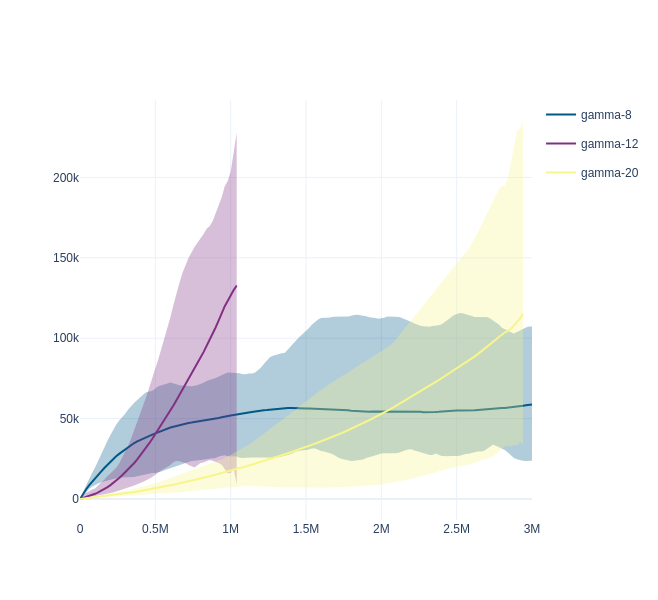

In [162]:
fig = go.Figure()
for gamma, group in aggdf.group_by("gamma"):
    gamma = gamma[0]
    color = grad(gamma)
    fig.add_traces([
        go.Scatter(
            x=group["dt"],
            y=group["mean"],
            mode="lines",
            line_color=color,
            name=f"gamma-{gamma}",
            legendgroup=gamma
        ),
        go.Scatter(
            x=pl.concat([group["dt"], group["dt"][::-1]]),
            y=pl.concat([group["min"], group["max"][::-1]]),
            mode="lines",
            line_color="rgba(0, 0, 0, 0)",
            fillcolor=color,
            opacity=0.3,
            fill="toself",
            hoverinfo="skip",
            showlegend=False,
            legendgroup=gamma
        )
    ])
fig.update_layout(
    template="plotly_white",
    width=400,
    height=600
)

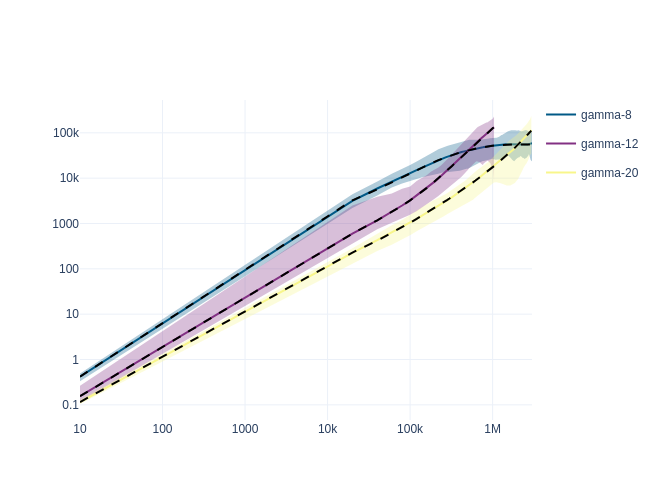

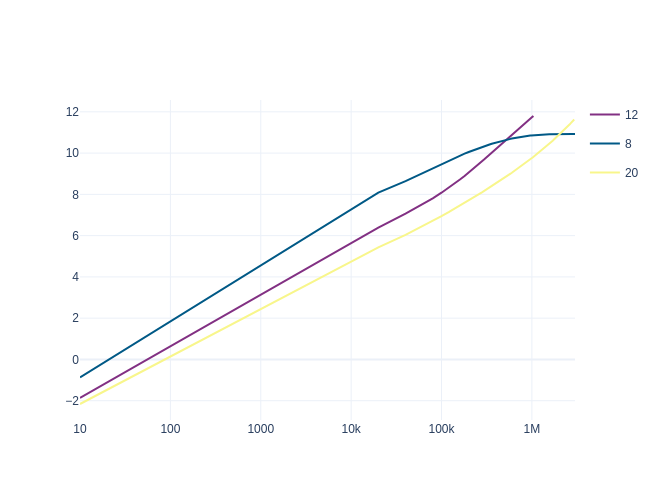

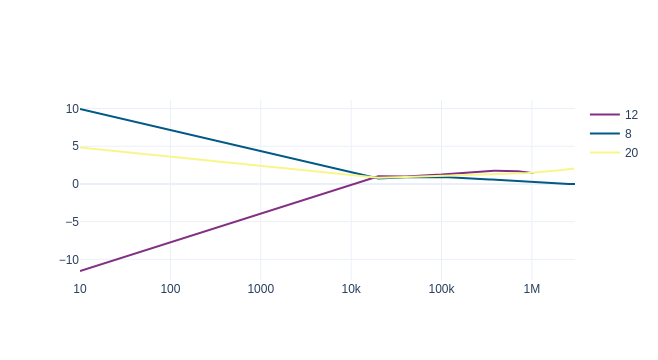

In [163]:
fig2 = go.Figure(fig.update_layout(
    xaxis_type="log",
    yaxis_type="log",
    width=500,
    height=500
))
fig3 = go.Figure()
fig4 = go.Figure()
for gamma, group in aggdf.group_by("gamma"):
    gamma = gamma[0]
    dt = group["dt"]
    log_dt = dt.log()
    mean = group["mean"]
    poly = np.polynomial.Polynomial.fit(x=dt.log(), y=mean.log(), deg=5).convert()
    fig2.add_trace(go.Scatter(
        x=dt,
        y=np.exp(poly(dt.log())),
        mode="lines",
        line_dash="dash",
        line_color="#000000",
        showlegend=False,
        legendgroup=gamma
    ))

    fig3.add_trace(go.Scatter(
        x=np.exp(log_dt),
        y=poly(log_dt),
        mode="lines",
        line_color=grad(gamma),
        name=gamma,
        legendgroup=gamma
    ))
    
    first_deriv = poly.deriv()
    fig4.add_trace(go.Scatter(
        x=np.exp(log_dt),
        y=first_deriv(log_dt),
        mode="lines",
        line_color=grad(gamma),
        name=str(gamma)
    ))
fig2.show()
fig3.update_layout(
    template="plotly_white",
    xaxis_type="log",
    width=500,
    height=500
).show()
fig4.update_layout(
    template="plotly_white",
    xaxis_type="log"
)